# QCM visuel — Séance 3  
**Gradient, contours et segmentation classique**

## Consignes
- Répondez directement dans les cellules prévues.
- Une seule lettre attendue : `A`, `B`, `C` ou `D`.
- Exécutez les cellules dans l'ordre.
- Ne modifiez pas les fonctions.
- Ne laissez pas de cellule vide.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.grid"] = False

def show_image(img, title="Image", cmap="gray", figsize=(6, 4)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_images(images, titles, ncols=3, cmap="gray", figsize=(14, 8)):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def gaussian_blur(image, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(image, (ksize, ksize), sigmaX=sigma)

def compute_sobel(image):
    image_f = image.astype(np.float32)
    gx = cv2.Sobel(image_f, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(image_f, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    angle_deg = (np.rad2deg(np.arctan2(gy, gx)) + 180) % 180
    return gx, gy, magnitude, angle_deg

def compute_roberts(image):
    image_f = image.astype(np.float32)
    kx = np.array([[1, 0],[0, -1]], dtype=np.float32)
    ky = np.array([[0, 1],[-1, 0]], dtype=np.float32)
    gx = cv2.filter2D(image_f, cv2.CV_32F, kx)
    gy = cv2.filter2D(image_f, cv2.CV_32F, ky)
    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude

def compute_prewitt(image):
    image_f = image.astype(np.float32)
    kx = np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -1, -1],[0, 0, 0],[1, 1, 1]], dtype=np.float32)
    gx = cv2.filter2D(image_f, cv2.CV_32F, kx)
    gy = cv2.filter2D(image_f, cv2.CV_32F, ky)
    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude

def normalize_to_uint8(image):
    norm = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    return norm.astype(np.uint8)

def threshold_gradient(magnitude, thresh):
    binary = np.zeros_like(magnitude, dtype=np.uint8)
    binary[magnitude >= thresh] = 255
    return binary

def apply_canny(image, low_thresh, high_thresh):
    return cv2.Canny(image, threshold1=low_thresh, threshold2=high_thresh)

def simple_threshold(image, thresh):
    _, binary = cv2.threshold(image, thresh, 255, cv2.THRESH_BINARY)
    return binary

def otsu_threshold(image):
    otsu_value, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return otsu_value, binary

def apply_watershed(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    sure_bg = cv2.dilate(opening, kernel, iterations=2)
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(color, markers)
    color_result = color.copy()
    color_result[markers == -1] = [255, 0, 0]
    return color_result, markers, sure_fg, unknown

img_camera = data.camera()
img_coins = data.coins()
img_moon = data.moon()

img_synth = np.zeros((256, 256), dtype=np.uint8)
cv2.rectangle(img_synth, (30, 30), (110, 180), 180, thickness=-1)
cv2.circle(img_synth, (180, 120), 45, 255, thickness=-1)
cv2.line(img_synth, (20, 220), (230, 220), 120, thickness=3)

rng = np.random.default_rng(123)
noise = rng.normal(0, 20, size=img_synth.shape)
img_synth_noisy = np.clip(img_synth.astype(np.float32) + noise, 0, 255).astype(np.uint8)
img_synth_blur = gaussian_blur(img_synth_noisy, ksize=5, sigma=1.2)

## Question 1 — Lecture d'une magnitude de gradient

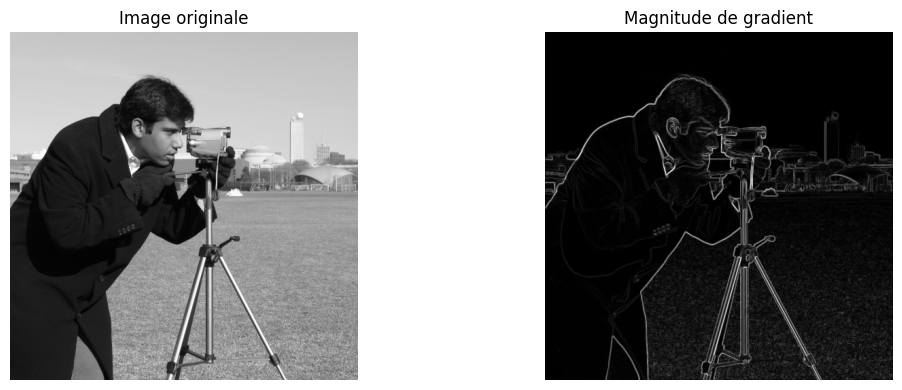

In [2]:
_, _, mag_cam, _ = compute_sobel(img_camera)
show_images(
    [img_camera, normalize_to_uint8(mag_cam)],
    ["Image originale", "Magnitude de gradient"],
    ncols=2,
    figsize=(12, 4)
)

Que représentent principalement les zones claires dans l'image de droite ?

A. Des régions uniformes  
B. Des variations locales fortes d'intensité  
C. Des objets déjà segmentés  
D. Un lissage gaussien

In [ ]:
reponse_q1 = "B"  

## Question 2 — Effet du prétraitement avant dérivation

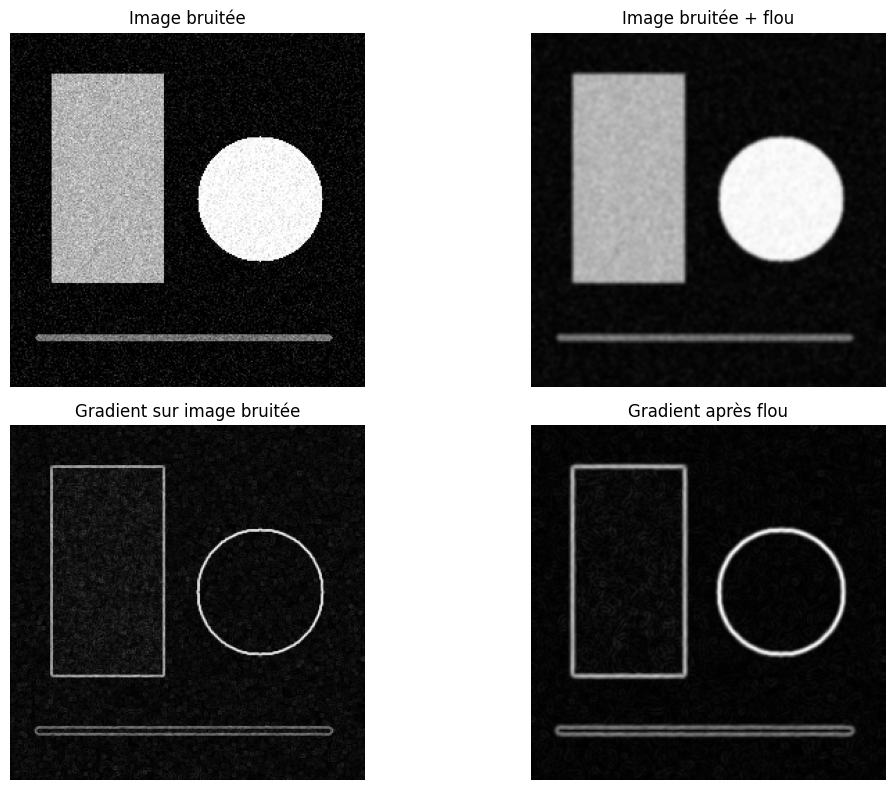

In [4]:
_, _, mag_noisy, _ = compute_sobel(img_synth_noisy)
_, _, mag_blur, _ = compute_sobel(img_synth_blur)
show_images(
    [img_synth_noisy, img_synth_blur, normalize_to_uint8(mag_noisy), normalize_to_uint8(mag_blur)],
    ["Image bruitée", "Image bruitée + flou", "Gradient sur image bruitée", "Gradient après flou"],
    ncols=2,
    figsize=(12, 8)
)

Quel est l'effet principal du flou gaussien avant le gradient ?

A. Il augmente la résolution  
B. Il supprime tous les contours  
C. Il réduit les faux gradients dus au bruit  
D. Il transforme le gradient en segmentation

In [ ]:
reponse_q2 = "C"  

## Question 3 — Comparer Roberts, Prewitt et Sobel

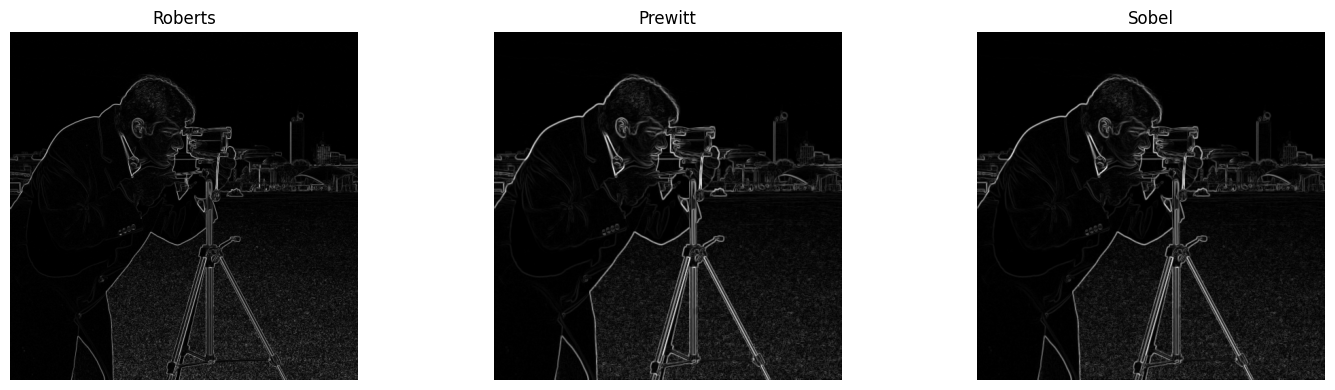

In [6]:
_, _, mag_r = compute_roberts(img_camera)
_, _, mag_p = compute_prewitt(img_camera)
_, _, mag_s, _ = compute_sobel(img_camera)
show_images(
    [normalize_to_uint8(mag_r), normalize_to_uint8(mag_p), normalize_to_uint8(mag_s)],
    ["Roberts", "Prewitt", "Sobel"],
    ncols=3,
    figsize=(15, 4)
)

À partir de cette comparaison, quel opérateur semble le plus robuste visuellement ?

A. Roberts  
B. Prewitt  
C. Sobel  
D. Aucun, ils sont strictement identiques

In [ ]:
reponse_q3 = "C"  

## Question 4 — Seuillage faible ou fort

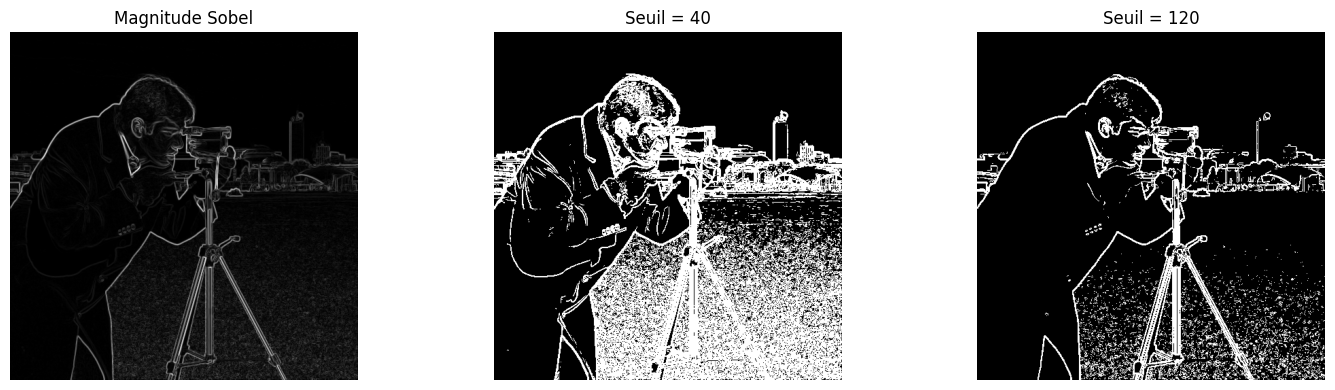

In [8]:
_, _, mag_sobel_raw, _ = compute_sobel(img_camera)
b40 = threshold_gradient(mag_sobel_raw, 40)
b120 = threshold_gradient(mag_sobel_raw, 120)
show_images(
    [normalize_to_uint8(mag_sobel_raw), b40, b120],
    ["Magnitude Sobel", "Seuil = 40", "Seuil = 120"],
    ncols=3,
    figsize=(15, 4)
)

Quelle affirmation est la plus juste ?

A. Le seuil 40 garde plus de détails mais aussi plus de parasites  
B. Le seuil 120 garde forcément plus de contours  
C. Les deux seuils produisent exactement la même chose  
D. Un seuil élevé améliore toujours la segmentation

In [ ]:
reponse_q4 = "A"  

## Question 5 — Canny et continuité des contours

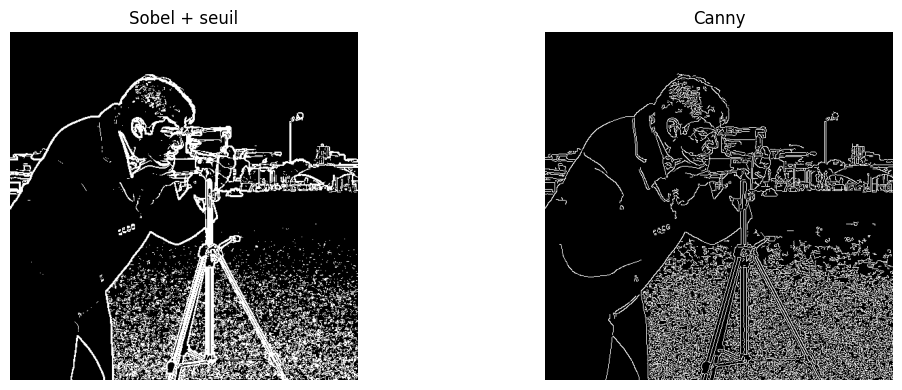

In [10]:
_, _, mag_sobel_raw, _ = compute_sobel(img_camera)
sobel_binary = threshold_gradient(mag_sobel_raw, 90)
canny_binary = apply_canny(img_camera, 50, 120)
show_images(
    [sobel_binary, canny_binary],
    ["Sobel + seuil", "Canny"],
    ncols=2,
    figsize=(12, 4)
)

Pourquoi les contours Canny paraissent-ils souvent plus cohérents ?

A. Parce que Canny applique l'hystérésis  
B. Parce que Canny change l'image en couleur  
C. Parce que Canny remplace le gradient par un histogramme  
D. Parce que Canny réalise directement un watershed

In [ ]:
reponse_q5 = "A"  

## Question 6 — Canny et choix des seuils

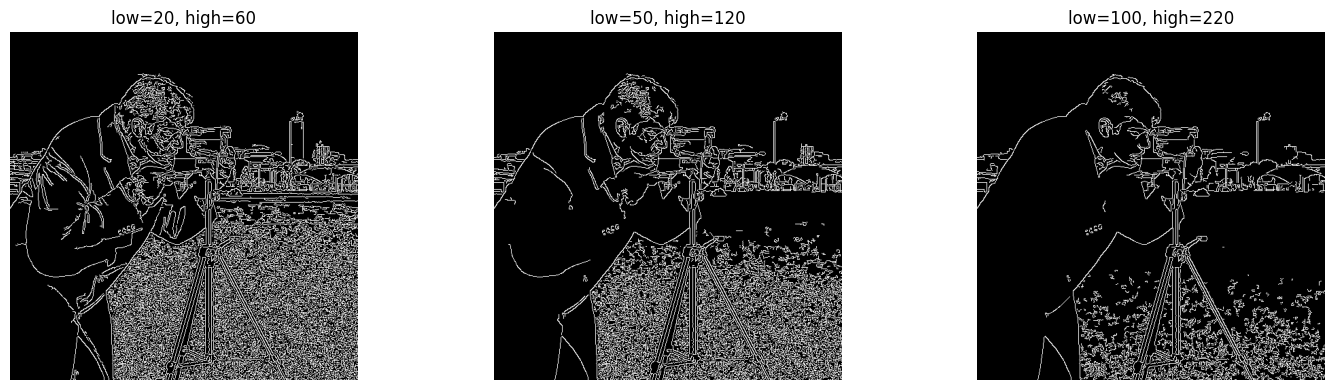

In [12]:
c1 = apply_canny(img_camera, 20, 60)
c2 = apply_canny(img_camera, 50, 120)
c3 = apply_canny(img_camera, 100, 220)
show_images(
    [c1, c2, c3],
    ["low=20, high=60", "low=50, high=120", "low=100, high=220"],
    ncols=3,
    figsize=(15, 4)
)

Quel couple de seuils risque de produire le résultat le plus pauvre en contours ?

A. low=20, high=60  
B. low=50, high=120  
C. low=100, high=220  
D. Les trois donnent forcément le même résultat

In [ ]:
reponse_q6 = "C"  

## Question 7 — Segmentation par seuil fixe

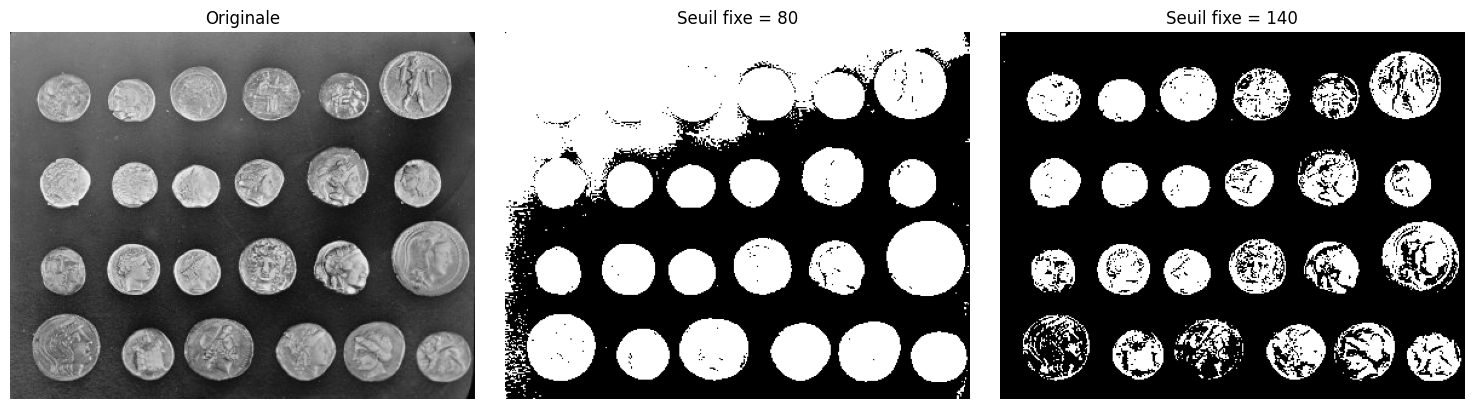

In [14]:
s80 = simple_threshold(img_coins, 80)
s140 = simple_threshold(img_coins, 140)
show_images(
    [img_coins, s80, s140],
    ["Originale", "Seuil fixe = 80", "Seuil fixe = 140"],
    ncols=3,
    figsize=(15, 4)
)

Que montre surtout cette comparaison ?

A. Le seuil fixe est indépendant du paramètre choisi  
B. La segmentation par seuil fixe dépend fortement du seuil  
C. Le seuillage fixe calcule un gradient  
D. Les deux segmentations sont des contours

In [ ]:
reponse_q7 = "B"  

## Question 8 — Otsu et histogramme

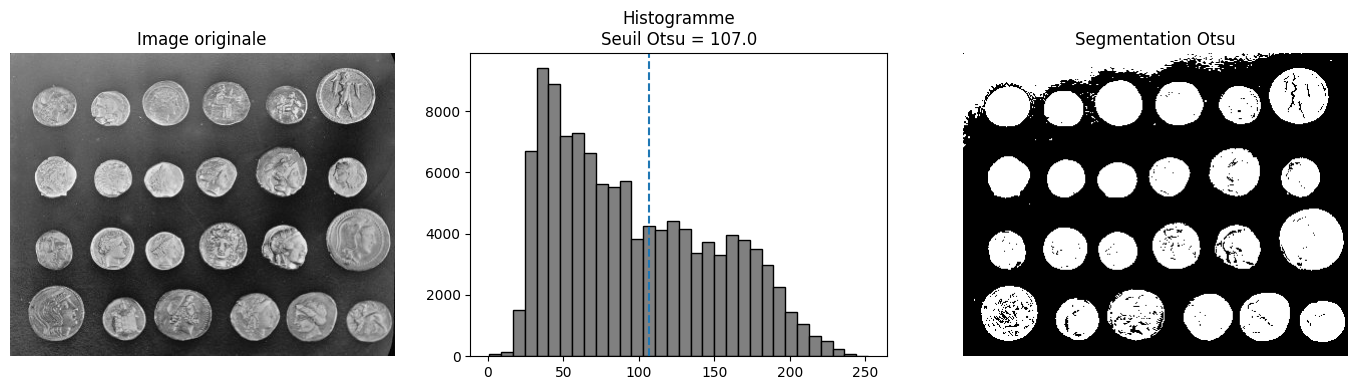

In [16]:
otsu_value, otsu_binary = otsu_threshold(img_coins)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_coins, cmap="gray")
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].hist(img_coins.ravel(), bins=32, color="gray", edgecolor="black")
axes[1].axvline(otsu_value, linestyle="--")
axes[1].set_title(f"Histogramme\nSeuil Otsu = {otsu_value:.1f}")
axes[2].imshow(otsu_binary, cmap="gray")
axes[2].set_title("Segmentation Otsu")
axes[2].axis("off")
plt.tight_layout()
plt.show()

Quel est l'intérêt principal d'Otsu ici ?

A. Choisir automatiquement un seuil global  
B. Détecter les orientations du gradient  
C. Produire des contours fins  
D. Réduire le bruit par convolution

In [ ]:
reponse_q8 = "A"  

## Question 9 — Contour ou segmentation ?

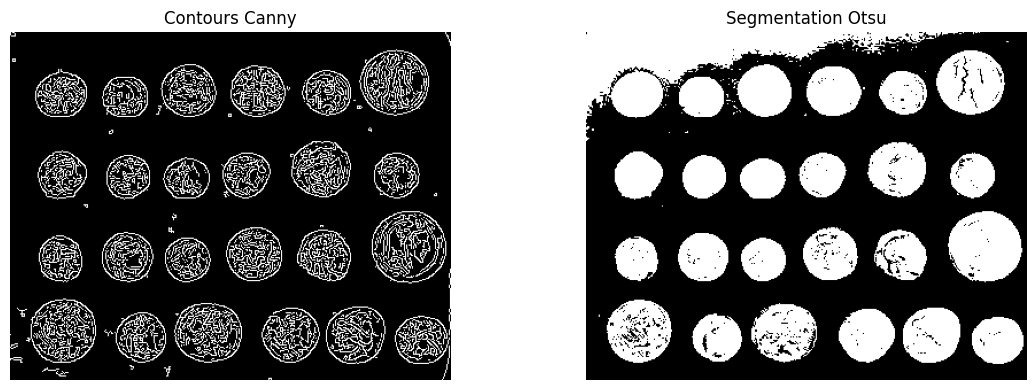

In [18]:
edges = apply_canny(img_coins, 50, 120)
_, otsu_bin = otsu_threshold(img_coins)
show_images(
    [edges, otsu_bin],
    ["Contours Canny", "Segmentation Otsu"],
    ncols=2,
    figsize=(12, 4)
)

Quelle phrase est correcte ?

A. Les deux images sont des segmentations  
B. Les deux images sont des cartes de gradient  
C. À gauche : contours ; à droite : segmentation  
D. À gauche : segmentation ; à droite : orientation du gradient

In [ ]:
reponse_q9 = "C"  

## Question 10 — Watershed guidé

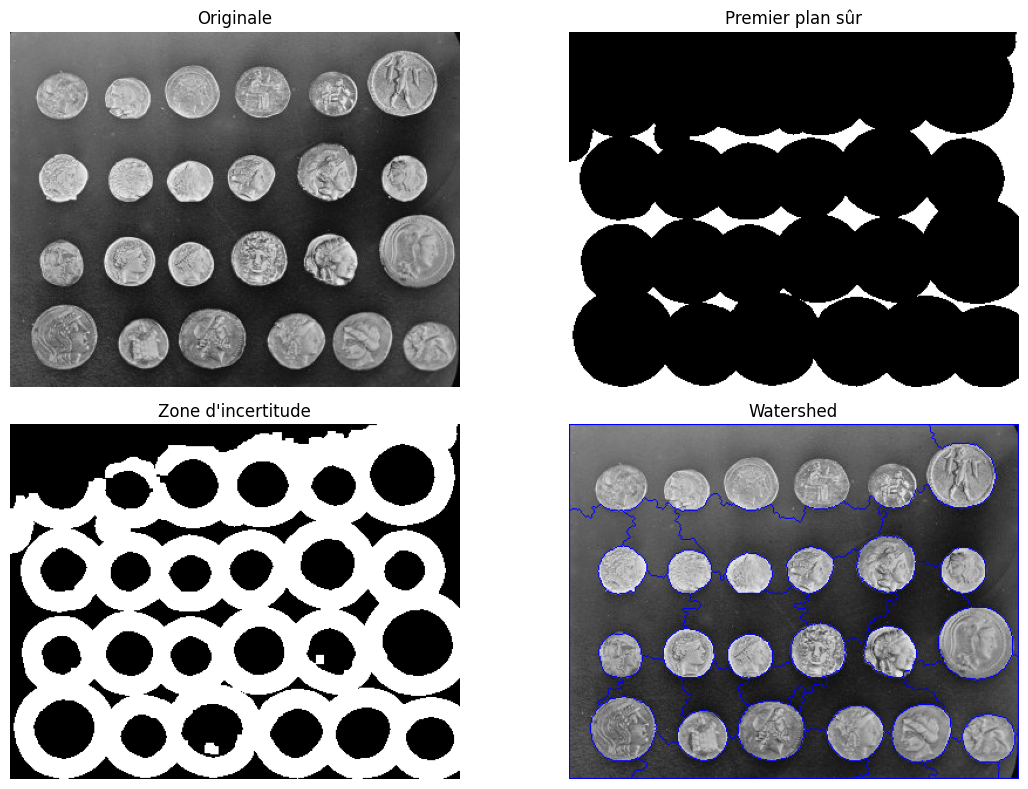

In [20]:
watershed_result, markers, sure_fg, unknown_zone = apply_watershed(img_coins)
show_images(
    [img_coins, sure_fg, unknown_zone, watershed_result],
    ["Originale", "Premier plan sûr", "Zone d'incertitude", "Watershed"],
    ncols=2,
    figsize=(12, 8)
)

Quel rôle jouent surtout les marqueurs dans watershed ?

A. Ils colorient l'image pour l'affichage  
B. Ils remplacent le gradient  
C. Ils guident la séparation des régions  
D. Ils calculent l'histogramme automatiquement

In [ ]:
reponse_q10 = "C" 

## Tableau final des réponses

réponses à insérer dans le code de notation